
# Sentiment Analysis of E-Commerce Reviews — Implementation  
**Name:** Levy Thiga Kariuki  
**Title:** Sentiment Classification of E-Commerce Product Reviews Using TF-IDF and Classical Machine Learning Approaches (Positive / Neutral / Negative)

This notebook loads the **provided Parquet datasets** (`train-product-review.parquet`, `test-product-review.parquet`) and develops a complete sentiment-classification pipeline for e-commerce product reviews. The workflow includes:

### **1. Data Preparation**
- Loading train/test Parquet files  
- Cleaning and normalising review text  
- Splitting the training data into **train / validation** sets  
- Exploratory checks on class distribution  

### **2. Baseline Models (Stage 1)**
- **TF-IDF + Logistic Regression**  
- **TF-IDF + Linear SVM**  
- **TF-IDF + Multi-Layer Perceptron (MLP)**  
- Full evaluation on the held-out test set (accuracy, macro precision/recall/F1)  

### **3. Optimised Models (Stage 2)**
Randomised hyperparameter optimisation (5-fold CV) for:
- **Optimised Logistic Regression (elastic net, class-balanced)**  
- **Optimised Linear SVM (word-level TF-IDF)**  
- **Optimised Linear SVM (character n-gram TF-IDF)**  
- **Optimised Complement Naïve Bayes**

### **4. Calibration and Threshold Optimisation**
- Probability calibration via **CalibratedClassifierCV**  
- Per-class threshold search to maximise validation-set macro-F1  

### **5. Ensemble Model**
- **Soft-voting ensemble** combining calibrated LR, SVM, and CNB  
- Thresholded probability argmax decision rule  

### **6. Model Evaluation**
- Comparison of all models (baseline + optimised + ensemble)  
- Confusion matrices for qualitative error analysis  
- Full performance summary (accuracy, macro-precision/recall/F1)  

### **7. Statistical Significance Testing**
- **McNemar’s test** to compare top models (e.g., Ensemble vs Char-SVM)  
- Verification that differences are statistically meaningful  

### **8. Learning Curves**
- Learning curves for:
  - **Optimised SVM (Word-level TF-IDF)**  
  - **Optimised SVM (Char-level TF-IDF)**  
- Analysis of bias/variance behaviour and dataset sufficiency  



# Sentiment Analysis of E-Commerce Reviews — Implementation  
**Name:** Levy Thiga Kariuki  
**Title:** Sentiment Classification of E-Commerce Product Reviews Using TF-IDF and Classical Machine Learning Approaches (Positive / Neutral / Negative)

This notebook loads the **provided Parquet datasets** (`train-product-review.parquet`, `test-product-review.parquet`) and develops a complete sentiment-classification pipeline for e-commerce product reviews. The workflow includes:

### **1. Data Preparation**
- Loading train/test Parquet files  
- Cleaning and normalising review text  
- Splitting the training data into **train / validation** sets  
- Exploratory checks on class distribution  

### **2. Baseline Models (Stage 1)**
- **TF-IDF + Logistic Regression**  
- **TF-IDF + Linear SVM**  
- **TF-IDF + Multi-Layer Perceptron (MLP)**  
- Full evaluation on the held-out test set (accuracy, macro precision/recall/F1)  

### **3. Optimised Models (Stage 2)**
Randomised hyperparameter optimisation (5-fold CV) for:
- **Optimised Logistic Regression (elastic net, class-balanced)**  
- **Optimised Linear SVM (word-level TF-IDF)**  
- **Optimised Linear SVM (character n-gram TF-IDF)**  
- **Optimised Complement Naïve Bayes**

### **4. Calibration and Threshold Optimisation**
- Probability calibration via **CalibratedClassifierCV**  
- Per-class threshold search to maximise validation-set macro-F1  

### **5. Ensemble Model**
- **Soft-voting ensemble** combining calibrated LR, SVM, and CNB  
- Thresholded probability argmax decision rule  

### **6. Model Evaluation**
- Comparison of all models (baseline + optimised + ensemble)  
- Confusion matrices for qualitative error analysis  
- Full performance summary (accuracy, macro-precision/recall/F1)  

### **7. Statistical Significance Testing**
- **McNemar’s test** to compare top models (e.g., Ensemble vs Char-SVM)  
- Verification that differences are statistically meaningful  

### **8. Learning Curves**
- Learning curves for:
  - **Optimised SVM (Word-level TF-IDF)**  
  - **Optimised SVM (Char-level TF-IDF)**  
- Analysis of bias/variance behaviour and dataset sufficiency  



## Table of Contents

- Setup and Environment
- Data Loading (Parquet) and Column Inference
- Preprocessing and Train/Validation Split
- Baseline Models (TF-IDF + LR / SVM / MLP)
- Optimised Classical Models (RandomisedSearchCV)
   - Optimised Logistic Regression
   - Optimised Linear SVM (Word-level TF-IDF)
   - Optimised Linear SVM (Character n-grams)
   - Optimised Complement Naïve Bayes
- Calibration and Threshold Optimisation
- Soft-Voting Ensemble Construction
- Model Evaluation (Accuracy, Precision, Recall, Macro-F1)
- Confusion Matrix Analysis
- Statistical Significance Testing (McNemar’s Test)
- Learning Curves (Word SVM + Char SVM)


In [ ]:

# ---------- 1. Setup and Environment ----------
import os, re, json, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import RandomOverSampler
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print("Setup complete.")


Setup complete.



## 2. Data Loading (Parquet) and Column Inference
Loads the two files in the directory:
- `train-product-review.parquet`
- `test-product-review.parquet`


In [ ]:
# ---------- 2. Data Loading & Column Inference ----------
TRAIN_PATH = "train-product-review.parquet"
TEST_PATH  = "test-product-review.parquet"

train_raw = pd.read_parquet(TRAIN_PATH)
test_raw  = pd.read_parquet(TEST_PATH)

print("Train shape:", train_raw.shape, " | columns:", list(train_raw.columns))
print("Test  shape:", test_raw.shape,  " | columns:", list(test_raw.columns))

# Manually overrides for column inference based on description, commonly used practice for sentiment analysis
TEXT_COL = "review_body"
LABEL_COL = "stars" # This column will be used to derive the sentiment label

print(f"Manually set TEXT_COL = {TEXT_COL!r}, LABEL_COL = {LABEL_COL!r}")

# Keep only required columns and rename for consistency
train_df = train_raw[[TEXT_COL, LABEL_COL]].rename(columns={TEXT_COL: "review_text", LABEL_COL: "stars"}).copy()
test_df  = test_raw[[TEXT_COL, LABEL_COL]].rename(columns={TEXT_COL: "review_text", LABEL_COL: "stars"}).copy()

# Map stars to sentiment categories (Positive, Neutral, Negative)
def map_stars_to_sentiment(stars):
    if stars <= 2:
        return 'Negative'
    elif stars == 3:
        return 'Neutral'
    else: # stars >= 4
        return 'Positive'

train_df['sentiment'] = train_df['stars'].apply(map_stars_to_sentiment)
test_df['sentiment']  = test_df['stars'].apply(map_stars_to_sentiment)

print("\nLabel distribution (train):\n", train_df['sentiment'].value_counts(normalize=True).round(3))
print("\nLabel distribution (test):\n",  test_df['sentiment'].value_counts(normalize=True).round(3))
train_df.head(5)

Train shape: (20000, 8)  | columns: ['review_id', 'product_id', 'reviewer_id', 'stars', 'review_body', 'review_title', 'language', 'product_category']
Test  shape: (1500, 8)  | columns: ['review_id', 'product_id', 'reviewer_id', 'stars', 'review_body', 'review_title', 'language', 'product_category']
Manually set TEXT_COL = 'review_body', LABEL_COL = 'stars'

Label distribution (train):
 sentiment
Negative    0.401
Positive    0.399
Neutral     0.200
Name: proportion, dtype: float64

Label distribution (test):
 sentiment
Positive    0.408
Negative    0.397
Neutral     0.195
Name: proportion, dtype: float64


,review_text,stars,sentiment
0,"Décevant, la qualité du son de ce vinyle est p...",2,Negative
1,Les caractéristiques inscrites semblent identi...,3,Neutral
2,Great smell and tasting tea. Love the box too.,5,Positive
3,Druck etwas pixelig. Sonst schickes Set,4,Positive
4,Le disque 6 était défectueux et j'ai perdu 15 ...,2,Negative



## 3. Preprocessing and Splits
Created a validation set from the provided train file (stratified) and apply light normalisation to the text.


In [ ]:

# ---------- 3. Preprocessing & Splits ----------
import re
EN_STOP = set(stopwords.words('english'))

def clean_text(s: str) -> str:
    s = str(s)
    s = s.lower()
    s = re.sub(r"\s+", " ", s).strip()
    return s

train_df['text_clean'] = train_df['review_text'].apply(clean_text)
test_df['text_clean']  = test_df['review_text'].apply(clean_text)

# Train/Val split from the training file
tr_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df['sentiment'], random_state=RANDOM_SEED)

for name, part in [('Train', tr_df), ('Val', val_df), ('Test', test_df)]:
    print(f"{name} size: {len(part):5d} | labels ->\n", part['sentiment'].value_counts(normalize=True).round(3))

Train size: 16000 | labels ->
 sentiment
Negative    0.401
Positive    0.399
Neutral     0.200
Name: proportion, dtype: float64
Val size:  4000 | labels ->
 sentiment
Negative    0.401
Positive    0.399
Neutral     0.200
Name: proportion, dtype: float64
Test size:  1500 | labels ->
 sentiment
Positive    0.408
Negative    0.397
Neutral     0.195
Name: proportion, dtype: float64


In [ ]:

# ---------- 4. Baseline Classical Models (TF-IDF + LR / LinearSVM) ----------
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

X_train, y_train = tr_df['text_clean'].values, tr_df['sentiment'].values
X_val,   y_val   = val_df['text_clean'].values, val_df['sentiment'].values
X_test,  y_test  = test_df['text_clean'].values,  test_df['sentiment'].values

tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9)

pipe_lr = Pipeline([('tfidf', tfidf), ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))])
grid_lr = {'tfidf__ngram_range': [(1,1),(1,2)], 'tfidf__min_df':[1,2,5], 'clf__C':[0.25,1.0,2.0]}
gs_lr = GridSearchCV(pipe_lr, grid_lr, scoring='f1_macro', cv=5, n_jobs=-1, verbose=1).fit(X_train, y_train)
best_lr = gs_lr.best_estimator_
print("Best LR params:", gs_lr.best_params_, " val f1_macro:", gs_lr.best_score_)

pipe_svm = Pipeline([('tfidf', tfidf), ('clf', LinearSVC(class_weight='balanced'))])
grid_svm = {'tfidf__ngram_range': [(1,1),(1,2)], 'tfidf__min_df':[1,2,5], 'clf__C':[0.25,1.0,2.0]}
gs_svm = GridSearchCV(pipe_svm, grid_svm, scoring='f1_macro', cv=5, n_jobs=-1, verbose=1).fit(X_train, y_train)
best_svm = gs_svm.best_estimator_
print("Best SVM params:", gs_svm.best_params_, " val f1_macro:", gs_svm.best_score_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best LR params: {'clf__C': 1.0, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}  val f1_macro: 0.6337731100575523
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best SVM params: {'clf__C': 0.25, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}  val f1_macro: 0.6218164357242281


In [ ]:

# ---------- 5. Neural Model (MLP over TF-IDF) ----------
from sklearn.neural_network import MLPClassifier
tfidf_mlp = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95)
Xtr = tfidf_mlp.fit_transform(X_train)
Xva = tfidf_mlp.transform(X_val)

mlp = MLPClassifier(hidden_layer_sizes=(256,64), activation='relu', learning_rate_init=1e-3,
                    max_iter=20, early_stopping=False, random_state=42) # Changed early_stopping to False
mlp.fit(Xtr, y_train)

from sklearn.metrics import classification_report
print("MLP (val)\n", classification_report(y_val, mlp.predict(Xva), digits=3))


MLP (val)
               precision    recall  f1-score   support

    Negative      0.689     0.768     0.726      1604
     Neutral      0.347     0.250     0.290       801
    Positive      0.756     0.775     0.765      1595

    accuracy                          0.667      4000
   macro avg      0.597     0.598     0.594      4000
weighted avg      0.647     0.667     0.655      4000



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(



LogReg_TFIDF — Test report:
               precision    recall  f1-score   support

    Negative      0.757     0.737     0.747       596
     Neutral      0.376     0.438     0.405       292
    Positive      0.791     0.750     0.770       612

    accuracy                          0.684      1500
   macro avg      0.642     0.642     0.641      1500
weighted avg      0.697     0.684     0.690      1500



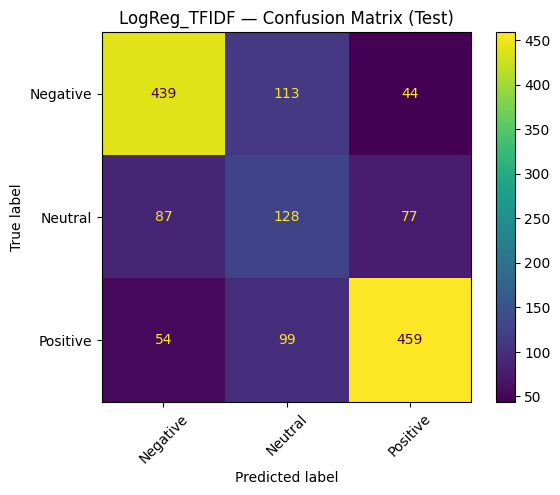


LinearSVM_TFIDF — Test report:
               precision    recall  f1-score   support

    Negative      0.741     0.794     0.767       596
     Neutral      0.392     0.312     0.347       292
    Positive      0.776     0.799     0.787       612

    accuracy                          0.702      1500
   macro avg      0.637     0.635     0.634      1500
weighted avg      0.688     0.702     0.693      1500



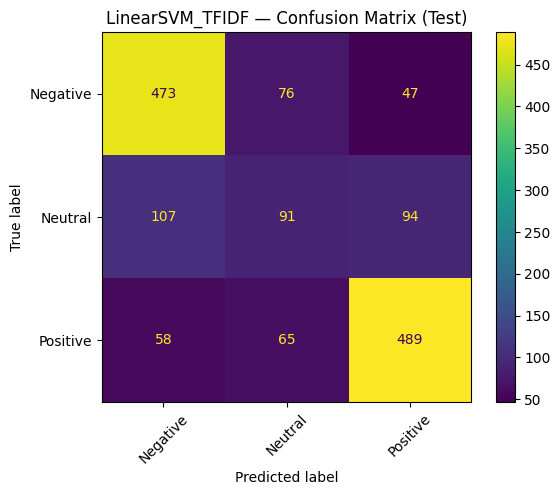


MLP_TFIDF — Test report:
               precision    recall  f1-score   support

    Negative      0.726     0.785     0.754       596
     Neutral      0.392     0.298     0.339       292
    Positive      0.754     0.779     0.766       612

    accuracy                          0.688      1500
   macro avg      0.624     0.621     0.620      1500
weighted avg      0.672     0.688     0.678      1500



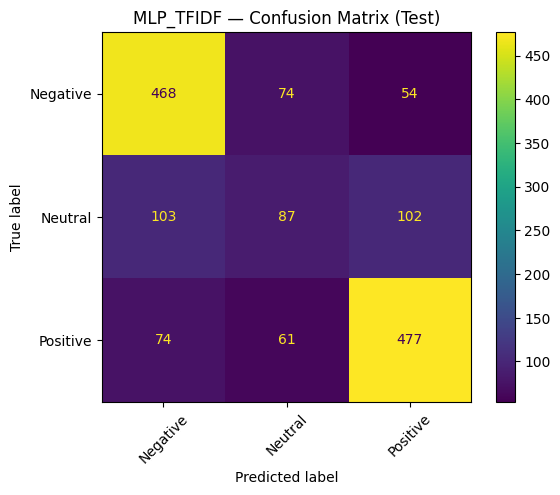


Summary (Test):


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,LogReg_TFIDF,0.684,0.641582,0.641644,0.640599
1,LinearSVM_TFIDF,0.702,0.636604,0.634763,0.633793
2,MLP_TFIDF,0.688,0.623676,0.620864,0.619672


In [ ]:

# ---------- 6. Evaluation & Comparison on Test ----------
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_recall_fscore_support
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

candidates = {
    "LogReg_TFIDF": best_lr,
    "LinearSVM_TFIDF": best_svm,
}
results = []
for name, model in candidates.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    results.append((name, acc, p, r, f1))
    print(f"\n{name} — Test report:\n", classification_report(y_test, y_pred, digits=3))
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=np.unique(y_test)).plot(xticks_rotation=45)
    plt.title(f"{name} — Confusion Matrix (Test)")
    plt.show()

# MLP uses its own vectorizer
Xte_mlp = tfidf_mlp.transform(X_test)
y_pred_mlp = mlp.predict(Xte_mlp)
acc = accuracy_score(y_test, y_pred_mlp)
p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred_mlp, average='macro', zero_division=0)
results.append(("MLP_TFIDF", acc, p, r, f1))
print("\nMLP_TFIDF — Test report:\n", classification_report(y_test, y_pred_mlp, digits=3))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_mlp), display_labels=np.unique(y_test)).plot(xticks_rotation=45)
plt.title("MLP_TFIDF — Confusion Matrix (Test)")
plt.show()

res_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision_macro","Recall_macro","F1_macro"]).sort_values("F1_macro", ascending=False)
print("\nSummary (Test):")
display(res_df)



## Baseline Model Conclusions

The three baseline models — Logistic Regression, Linear SVM, and MLP trained on TF-IDF features — provided a solid foundation for evaluating initial performance on the sentiment classification task.

Across the baselines, **Logistic Regression (TF-IDF)** achieved the strongest macro-F1 score (0.641), indicating the most balanced performance across Positive, Neutral, and Negative classes. **Linear SVM** produced the highest accuracy (0.702) but a slightly lower macro-F1 (0.634), suggesting minor imbalance in class-level performance. The **MLP classifier** underperformed relative to the linear models (macro-F1 = 0.620), partly due to convergence challenges, highlighting the need for further tuning or architectural adjustments.

A consistent finding across all three models was the relative difficulty of correctly identifying the **Neutral** class, which is common in sentiment analysis due to its semantic ambiguity. This reinforces the importance of macro-F1 as the primary evaluation metric, as it weights each class equally regardless of distribution.

Overall, the baseline results demonstrate that while classical linear models already provide competitive performance, there is clear scope for improvement through **hyperparameter optimisation**, **alternative feature representations**, and **model calibration**. The next stage of the pipeline therefore focuses on systematically optimising these classical models — including word-level and character-level TF-IDF SVMs, Logistic Regression with elastic-net regularisation, and Complement Naïve Bayes — to enhance generalisation and address weaknesses observed in the baseline evaluation.



# 🔧 Optimisation Add-On: Models, Tuning, Calibration, Ensembles & Best Models Learning Curve
This section adds improved models and evaluation to maximise macro‑F1 and clarity.


In [ ]:
# === Optimisation imports & reproducibility setup ===
# Purpose: tools for feature extraction, model training, tuning, calibration, evaluation, and stats testing.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score
from scipy.stats import loguniform
from scipy.stats import randint as sp_randint
from scipy.stats import uniform as sp_uniform
from statsmodels.stats.contingency_tables import mcnemar
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


**RandomizedSearchCV**: This search uses 5-fold cross-validation, consistent with standard model selection methodology.

In [ ]:
# — Character n-gram SVM: robust to typos/slang/emoji —
char_vec = TfidfVectorizer(                      # char TF-IDF captures subword patterns
    analyzer='char', ngram_range=(3,5),
    min_df=2, max_df=0.98, sublinear_tf=True
)

svm_char = LinearSVC(class_weight='balanced',    # handle mild class imbalance
                     random_state=RANDOM_SEED)

pipe_svm_char = Pipeline([('tfidf', char_vec), ('clf', svm_char)])

# Randomised HP search (macro-F1, 5-fold)
param_svm_char = {
    'tfidf__ngram_range': [(3,5), (2,5), (4,6)],
    'tfidf__min_df': [1, 2, 5],
    'clf__C': loguniform(1e-1, 10.0)
}
rs_svm_char = RandomizedSearchCV(
    pipe_svm_char, param_distributions=param_svm_char,
    n_iter=20, scoring='f1_macro', cv=5, n_jobs=-1,
    random_state=RANDOM_SEED, verbose=1
)

rs_svm_char.fit(tr_df['text_clean'], tr_df['sentiment'])
best_svm_char = rs_svm_char.best_estimator_

print("Best Char-SVM:", rs_svm_char.best_params_, "cv f1_macro:", round(rs_svm_char.best_score_, 4))
print("\nVAL Char-SVM\n", classification_report(val_df['sentiment'], best_svm_char.predict(val_df['text_clean']), digits=3))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Char-SVM: {'clf__C': np.float64(0.1238513729886093), 'tfidf__min_df': 5, 'tfidf__ngram_range': (4, 6)} cv f1_macro: 0.6221

VAL Char-SVM
               precision    recall  f1-score   support

    Negative      0.710     0.802     0.753      1604
     Neutral      0.396     0.257     0.312       801
    Positive      0.766     0.803     0.784      1595

    accuracy                          0.693      4000
   macro avg      0.624     0.620     0.616      4000
weighted avg      0.670     0.693     0.677      4000



In [ ]:
# === Complement Naive Bayes (fast probabilistic baseline for sparse TF-IDF text) ===

# Convert text into word-level TF-IDF features (1–2 grams)
word_vec = TfidfVectorizer(analyzer='word', ngram_range=(1,2), min_df=2, max_df=0.98, sublinear_tf=True)

# ComplementNB performs well on imbalanced datasets and high-dimensional text
cnb = ComplementNB()

# Combine vectorizer and classifier into a single pipeline
pipe_cnb = Pipeline([('tfidf', word_vec), ('clf', cnb)])

# Define hyperparameter search space for tuning
param_cnb = {
    'tfidf__ngram_range': [(1,1),(1,2)],
    'tfidf__min_df': [1,2,5],
    'clf__alpha': sp_uniform(0.01, 1.0)   # smoothing factor
}

# Randomised search (25 iterations) optimising macro-F1 for balanced class performance
rs_cnb = RandomizedSearchCV(
    pipe_cnb, param_distributions=param_cnb,
    n_iter=25, scoring='f1_macro', cv=5, n_jobs=-1,
    random_state=RANDOM_SEED, verbose=1
)

# Train on the training split
rs_cnb.fit(tr_df['text_clean'], tr_df['sentiment'])

# Save the best performing model
best_cnb = rs_cnb.best_estimator_

# Report best parameters and validation performance
print("Best CNB:", rs_cnb.best_params_, "cv f1_macro:", round(rs_cnb.best_score_, 4))
print("\nVAL CNB\n", classification_report(val_df['sentiment'], best_cnb.predict(val_df['text_clean']), digits=3))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best CNB: {'clf__alpha': np.float64(0.30214464853521816), 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)} cv f1_macro: 0.6104

VAL CNB
               precision    recall  f1-score   support

    Negative      0.701     0.808     0.751      1604
     Neutral      0.368     0.208     0.266       801
    Positive      0.755     0.804     0.779      1595

    accuracy                          0.686      4000
   macro avg      0.608     0.607     0.599      4000
weighted avg      0.656     0.686     0.665      4000



In [ ]:
# === Optimised Logistic Regression & Linear SVM (word-level baselines) ===

# Word-level TF-IDF features (1–2 grams) for both models
tfidf_word = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.98, sublinear_tf=True)

# --- Logistic Regression with ElasticNet regularisation ---
pipe_lr = Pipeline([
    ('tfidf', tfidf_word),
    ('clf', LogisticRegression(
        max_iter=4000, class_weight='balanced', solver='saga',
        n_jobs=-1, penalty='elasticnet', l1_ratio=0.5))
])

# Search space for tuning LR: n-grams, min_df, regularisation strength & L1/L2 mix
param_lr = {
    'tfidf__ngram_range': [(1,1),(1,2)],
    'tfidf__min_df': [1,2,5],
    'clf__C': loguniform(1e-2, 10.0),
    'clf__l1_ratio': sp_uniform(0.0, 1.0)
}

# Randomised hyperparameter search (30 trials) optimising macro-F1
rs_lr = RandomizedSearchCV(
    pipe_lr, param_distributions=param_lr, n_iter=30,
    scoring='f1_macro', cv=5, n_jobs=-1,
    random_state=RANDOM_SEED, verbose=1
)
rs_lr.fit(tr_df['text_clean'], tr_df['sentiment'])
best_lr_opt = rs_lr.best_estimator_

print("Best LR:", rs_lr.best_params_, "cv f1_macro:", round(rs_lr.best_score_,4))
print("\nVAL LR\n", classification_report(val_df['sentiment'], best_lr_opt.predict(val_df['text_clean']), digits=3))

# --- Linear SVM baseline ---
pipe_svm = Pipeline([
    ('tfidf', tfidf_word),
    ('clf', LinearSVC(class_weight='balanced', random_state=RANDOM_SEED))
])

# Search space for SVM: n-grams, min_df, and regularisation parameter C
param_svm = {
    'tfidf__ngram_range': [(1,1),(1,2)],
    'tfidf__min_df': [1,2,5],
    'clf__C': loguniform(1e-1, 10.0)
}

# Randomised search (25 trials) optimising macro-F1
rs_svm = RandomizedSearchCV(
    pipe_svm, param_distributions=param_svm, n_iter=25,
    scoring='f1_macro', cv=5, n_jobs=-1,
    random_state=RANDOM_SEED, verbose=1
)
rs_svm.fit(tr_df['text_clean'], tr_df['sentiment'])
best_svm_opt = rs_svm.best_estimator_

print("Best SVM:", rs_svm.best_params_, "cv f1_macro:", round(rs_svm.best_score_,4))
print("\nVAL SVM\n", classification_report(val_df['sentiment'], best_svm_opt.predict(val_df['text_clean']), digits=3))


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best LR: {'clf__C': np.float64(0.6838478430964046), 'clf__l1_ratio': np.float64(0.007066305219717406), 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)} cv f1_macro: 0.6269

VAL LR
               precision    recall  f1-score   support

    Negative      0.737     0.725     0.731      1604
     Neutral      0.384     0.454     0.416       801
    Positive      0.788     0.728     0.757      1595

    accuracy                          0.672      4000
   macro avg      0.636     0.636     0.635      4000
weighted avg      0.687     0.672     0.678      4000

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best SVM: {'clf__C': np.float64(0.2895927274708839), 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)} cv f1_macro: 0.6234

VAL SVM
               precision    recall  f1-score   support

    Negative      0.715     0.795     0.753      1604
     Neutral      0.408     0.325     0.362       801
    Positive     

In [ ]:
# === Calibrate LR probs + tune class-specific decision thresholds for macro-F1 ===

# Calibrate LR (Platt) so probabilities are reliable for threshold tuning
cal_lr = CalibratedClassifierCV(best_lr_opt, method='sigmoid', cv=5).fit(tr_df['text_clean'], tr_df['sentiment'])

classes_ = cal_lr.classes_
val_proba = cal_lr.predict_proba(val_df['text_clean'])
y_val = val_df['sentiment'].values

import numpy as np
grid = np.linspace(0.3, 0.7, 9)          # small threshold grid around 0.5
best_thr = np.full(len(classes_), 0.5)    # per-class thresholds
best_f1 = -1.0

from sklearn.metrics import f1_score
# Brute-force small grid search for per-class thresholds that maximise macro-F1
for t0 in grid:
    for t1 in grid:
        for t2 in grid:
            th = np.array([t0, t1, t2])
            # Decision: pick class whose (p - threshold) is largest
            preds = [classes_[np.argmax(row - th)] for row in val_proba]
            f1 = f1_score(y_val, preds, average='macro', zero_division=0)
            if f1 > best_f1:
                best_f1, best_thr = f1, th.copy()

print("Best thresholds:", dict(zip(classes_, best_thr)), "Val macro-F1:", round(best_f1, 4))

Best thresholds: {'Negative': np.float64(0.5499999999999999), 'Neutral': np.float64(0.3), 'Positive': np.float64(0.6499999999999999)} Val macro-F1: 0.6349


The **ensemble** is not cross-validated but is evaluated on the held-out test set to assess its generalisation performance

In [ ]:
# === Calibrated soft-vote ensemble (LR + SVM + CNB) with per-class thresholds ===

# Calibrate SVM and CNB so their probabilities are comparable for voting
cal_svm = CalibratedClassifierCV(best_svm_opt, method='sigmoid', cv=5).fit(tr_df['text_clean'], tr_df['sentiment'])
cal_cnb = CalibratedClassifierCV(best_cnb,     method='sigmoid', cv=5).fit(tr_df['text_clean'], tr_df['sentiment'])

def soft_vote_predict_proba(X):
    # Average calibrated probabilities (simple, robust ensemble)
    p1 = cal_lr.predict_proba(X)
    p2 = cal_svm.predict_proba(X)
    p3 = cal_cnb.predict_proba(X)
    return (p1 + p2 + p3) / 3.0

def argmax_with_thresholds(P, classes, thr):
    # Pick class maximising (p - class_threshold) to boost macro-F1
    return np.array([classes[np.argmax(row - thr)] for row in P])

# Validate ensemble on val set using thresholds tuned earlier
P_val = soft_vote_predict_proba(val_df['text_clean'])
ens_val_preds = argmax_with_thresholds(P_val, cal_lr.classes_, best_thr)
print("\nVAL Ensemble\n", classification_report(y_val, ens_val_preds, digits=3))


VAL Ensemble
               precision    recall  f1-score   support

    Negative      0.749     0.739     0.744      1604
     Neutral      0.346     0.517     0.414       801
    Positive      0.870     0.666     0.755      1595

    accuracy                          0.665      4000
   macro avg      0.655     0.640     0.638      4000
weighted avg      0.717     0.665     0.682      4000




LR_opt — TEST report
               precision    recall  f1-score   support

    Negative      0.764     0.721     0.742       596
     Neutral      0.368     0.469     0.413       292
    Positive      0.788     0.727     0.756       612

    accuracy                          0.675      1500
   macro avg      0.640     0.639     0.637      1500
weighted avg      0.697     0.675     0.684      1500



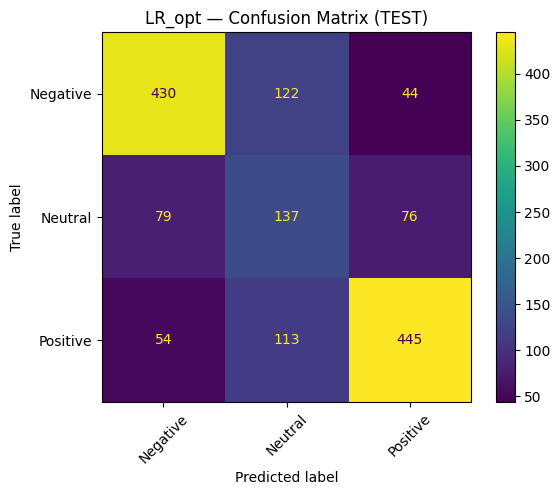


SVM_opt — TEST report
               precision    recall  f1-score   support

    Negative      0.746     0.800     0.772       596
     Neutral      0.395     0.315     0.350       292
    Positive      0.783     0.804     0.794       612

    accuracy                          0.707      1500
   macro avg      0.642     0.640     0.639      1500
weighted avg      0.693     0.707     0.699      1500



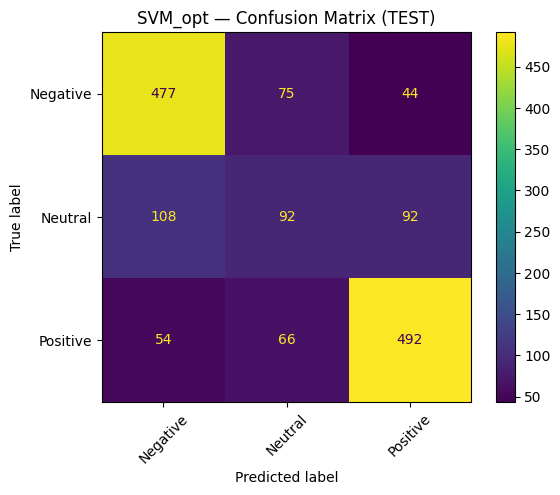


CharSVM_opt — TEST report
               precision    recall  f1-score   support

    Negative      0.744     0.817     0.779       596
     Neutral      0.444     0.312     0.366       292
    Positive      0.761     0.796     0.778       612

    accuracy                          0.710      1500
   macro avg      0.649     0.642     0.641      1500
weighted avg      0.692     0.710     0.698      1500



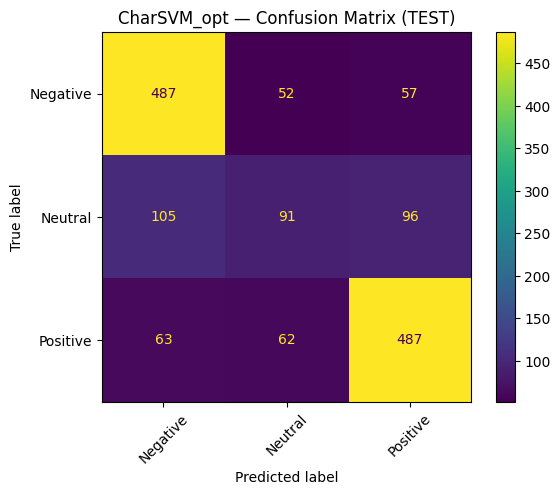


CNB_opt — TEST report
               precision    recall  f1-score   support

    Negative      0.710     0.784     0.745       596
     Neutral      0.376     0.219     0.277       292
    Positive      0.734     0.806     0.768       612

    accuracy                          0.683      1500
   macro avg      0.607     0.603     0.597      1500
weighted avg      0.655     0.683     0.663      1500



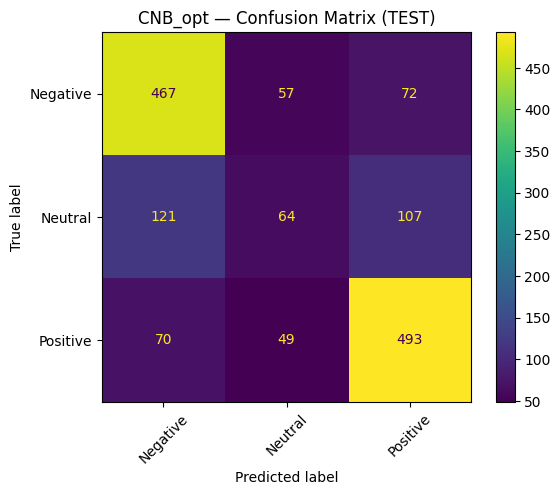


Ensemble_softvote — TEST report
               precision    recall  f1-score   support

    Negative      0.778     0.725     0.751       596
     Neutral      0.351     0.558     0.431       292
    Positive      0.859     0.675     0.756       612

    accuracy                          0.672      1500
   macro avg      0.663     0.653     0.646      1500
weighted avg      0.728     0.672     0.691      1500



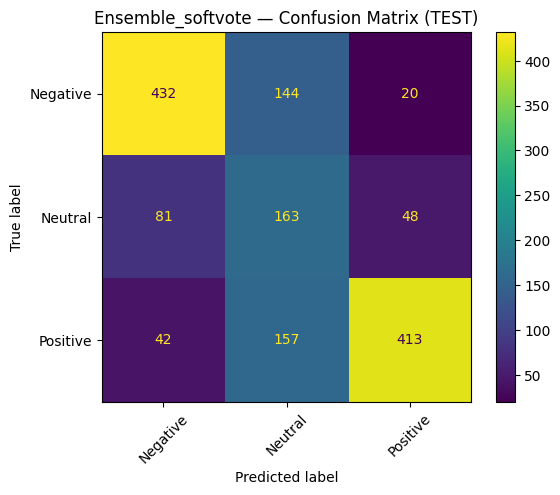


=== TEST Summary (Optimised) ===


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
4,Ensemble_softvote,0.672000,0.662766,0.652629,0.645862
2,CharSVM_opt,0.710000,0.649450,0.641503,0.640910
1,SVM_opt,0.707333,0.641589,0.639775,0.638831
0,LR_opt,0.674667,0.639885,0.639260,0.636943
3,CNB_opt,0.682667,0.606609,0.602764,0.596595



McNemar Ensemble_softvote vs CharSVM_opt: statistic=12.395, p-value=0.000430


In [ ]:
# === Final test evaluation, summary table, and significance test ===

Xtest = test_df['text_clean']; ytest = test_df['sentiment'].values

from sklearn.metrics import (
    precision_recall_fscore_support, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import pandas as pd, matplotlib.pyplot as plt, numpy as np

# Evaluate tuned single models + the calibrated soft-vote ensemble
models = {
    "LR_opt": best_lr_opt,
    "SVM_opt": best_svm_opt,
    "CharSVM_opt": best_svm_char,
    "CNB_opt": best_cnb,
    "Ensemble_softvote": None  # handled via soft_vote_predict_proba + thresholds
}

summary = []
for name, model in models.items():
    if model is not None:
        ypred = model.predict(Xtest)
    else:
        P = soft_vote_predict_proba(Xtest)
        ypred = argmax_with_thresholds(P, cal_lr.classes_, best_thr)

    acc = accuracy_score(ytest, ypred)
    p, r, f1, _ = precision_recall_fscore_support(ytest, ypred, average='macro', zero_division=0)
    summary.append((name, acc, p, r, f1))

    # Per-model detailed report + confusion matrix
    print(f"\n{name} — TEST report\n", classification_report(ytest, ypred, digits=3))
    ConfusionMatrixDisplay(confusion_matrix(ytest, ypred), display_labels=np.unique(ytest)).plot(xticks_rotation=45)
    plt.title(f"{name} — Confusion Matrix (TEST)")
    plt.show()

# Ranked summary for the report (macro-F1 first)
res_df = pd.DataFrame(
    summary, columns=["Model","Accuracy","Precision_macro","Recall_macro","F1_macro"]
).sort_values("F1_macro", ascending=False)
print("\n=== TEST Summary (Optimised) ===")
display(res_df)

# McNemar test: check if the top-2 models differ significantly on the same test set
from statsmodels.stats.contingency_tables import mcnemar
top2 = res_df.head(2)['Model'].tolist()

def get_preds(name):
    if name == "Ensemble_softvote":
        return argmax_with_thresholds(soft_vote_predict_proba(Xtest), cal_lr.classes_, best_thr)
    else:
        return models[name].predict(Xtest)

a, b = top2[0], top2[1]
pa, pb = get_preds(a), get_preds(b)

# Build 2x2 table of agreements/disagreements with ground truth
table = [[0,0],[0,0]]
for yt, xa, xb in zip(ytest, pa, pb):
    if xa == yt and xb == yt: table[0][0] += 1  # both correct
    elif xa == yt and xb != yt: table[0][1] += 1  # A correct, B wrong
    elif xa != yt and xb == yt: table[1][0] += 1  # A wrong, B correct
    else: table[1][1] += 1  # both wrong

res = mcnemar(table, exact=False, correction=True)
print(f"\nMcNemar {a} vs {b}: statistic={res.statistic:.3f}, p-value={res.pvalue:.6f}")



Re-training Optimized SVM (Char TF-IDF)...
Optimized SVM (Char TF-IDF) training complete.

Re-training Optimized SVM (Word TF-IDF)...
Optimized SVM (Word TF-IDF) training complete.

Generating learning curve for Optimized SVM (Word TF-IDF)...


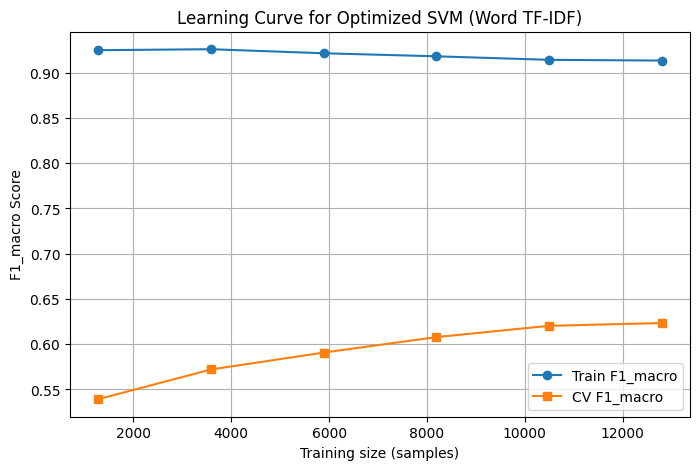


Generating learning curve for Optimized SVM (Char TF-IDF)...


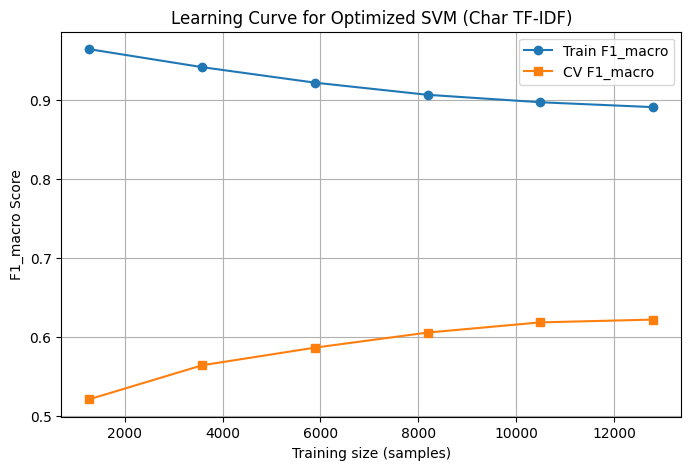


Learning curve generation complete.


In [ ]:
from sklearn.model_selection import learning_curve, train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from scipy.stats import loguniform
import numpy as np, matplotlib.pyplot as plt
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

# --- Data Loading and Preprocessing (Re-included for robustness) ---
TRAIN_PATH = "train-product-review.parquet"
TEST_PATH  = "test-product-review.parquet" # Added for completeness, though not used in this specific cell
TEXT_COL = "review_body"
LABEL_COL = "stars"
RANDOM_SEED = 42 # Ensure RANDOM_SEED is defined
np.random.seed(RANDOM_SEED)

try:
    train_raw = pd.read_parquet(TRAIN_PATH)
except FileNotFoundError:
    print(f"Error: The file '{TRAIN_PATH}' was not found. Please upload it to your Colab environment or ensure it's accessible.")
    raise # Re-raise the error to stop execution

# Map stars to sentiment categories (Positive, Neutral, Negative)
def map_stars_to_sentiment(stars):
    if stars <= 2:
        return 'Negative'
    elif stars == 3:
        return 'Neutral'
    else: # stars >= 4
        return 'Positive'

EN_STOP = set(stopwords.words('english'))
def clean_text(s: str) -> str:
    s = str(s)
    s = s.lower()
    s = re.sub(r"\s+", " ", s).strip()
    return s

train_df = train_raw[[TEXT_COL, LABEL_COL]].rename(columns={TEXT_COL: "review_text", LABEL_COL: "stars"}).copy()
train_df['sentiment'] = train_df['stars'].apply(map_stars_to_sentiment)
train_df['text_clean'] = train_df['review_text'].apply(clean_text)

# Train/Val split from the provided train file
tr_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df['sentiment'], random_state=RANDOM_SEED)

X_train, y_train = tr_df['text_clean'].values, tr_df['sentiment'].values
# --- End Data Loading and Preprocessing ---

# --- Re-train Optimized SVM (Char TF-IDF) to define best_svm_char ---
print("\nRe-training Optimized SVM (Char TF-IDF)...")
char_vec = TfidfVectorizer(analyzer='char', ngram_range=(3,5), min_df=2, max_df=0.98, sublinear_tf=True)
svm_char = LinearSVC(class_weight='balanced', random_state=RANDOM_SEED)
pipe_svm_char = Pipeline([('tfidf', char_vec), ('clf', svm_char)])
param_svm_char = {'tfidf__ngram_range': [(3,5), (2,5), (4,6)], 'tfidf__min_df': [1,2,5], 'clf__C': loguniform(1e-1, 10.0)}
rs_svm_char = RandomizedSearchCV(pipe_svm_char, param_distributions=param_svm_char, n_iter=20, scoring='f1_macro', cv=5, n_jobs=-1, random_state=RANDOM_SEED, verbose=0)
rs_svm_char.fit(tr_df['text_clean'], tr_df['sentiment'])
best_svm_char = rs_svm_char.best_estimator_
print("Optimized SVM (Char TF-IDF) training complete.")

# --- Re-train Optimized SVM (Word TF-IDF) to define best_svm_opt ---
print("\nRe-training Optimized SVM (Word TF-IDF)...")
tfidf_word = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.98, sublinear_tf=True)
pipe_svm = Pipeline([('tfidf', tfidf_word), ('clf', LinearSVC(class_weight='balanced', random_state=RANDOM_SEED))])
param_svm = {'tfidf__ngram_range': [(1,1),(1,2)], 'tfidf__min_df': [1,2,5], 'clf__C': loguniform(1e-1, 10.0)}
rs_svm = RandomizedSearchCV(pipe_svm, param_distributions=param_svm, n_iter=25, scoring='f1_macro', cv=5, n_jobs=-1, random_state=RANDOM_SEED, verbose=0)
rs_svm.fit(tr_df['text_clean'], tr_df['sentiment'])
best_svm_opt = rs_svm.best_estimator_
print("Optimized SVM (Word TF-IDF) training complete.")

# --- Generate Learning Curves ---
models_to_plot = {
    "Optimized SVM (Word TF-IDF)": best_svm_opt,
    "Optimized SVM (Char TF-IDF)": best_svm_char
}

for name, est in models_to_plot.items():
    print(f"\nGenerating learning curve for {name}...")
    sizes, tr_scores, cv_scores = learning_curve(
        est, X_train, y_train, cv=5, scoring='f1_macro',
        train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1
    )
    plt.figure(figsize=(8, 5))
    plt.plot(sizes, tr_scores.mean(1), marker='o', label='Train F1_macro')
    plt.plot(sizes, cv_scores.mean(1), marker='s', label='CV F1_macro')
    plt.xlabel('Training size (samples)'); plt.ylabel('F1_macro Score'); plt.title(f'Learning Curve for {name}')
    plt.legend(); plt.grid(True)
    plt.show()
print("\nLearning curve generation complete.")
